# Local Training - Apple M1/M2 (MPS)

Train all 6 chess models locally on Apple Silicon using Metal Performance Shaders.

## Models
- **CNN**: ConvNet, ResNet
- **Transformer**: SquareTransformer, PieceTransformer  
- **GNN**: GCN, GAT

## Continual Learning Strategy
When resuming on new data chunks:
- Uses **lower learning rate** (10x) to avoid catastrophic forgetting
- Fresh optimizer (no stale momentum from old data)
- Fewer epochs for fine-tuning

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project: {PROJECT_ROOT}")

Project: /Users/bhavya/Documents/FYP/project


In [2]:
import gc
import json
import time
from glob import glob
from typing import Optional, Callable
from dataclasses import dataclass

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import chess

print(f"PyTorch: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

/Users/bhavya/.pyenv/versions/3.14.0/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.10.0
MPS available: True
MPS built: True


In [3]:
from src.models.factory import create_model, get_encoder_for_model
from src.chess_env.board_wrapper import UCI_MOVE_TO_INDEX, NUM_MOVES
from src.config import load_config

print(f"UCI moves: {NUM_MOVES}")

UCI moves: 4544


## 2. Configuration

In [7]:
# ============================================================
# TRAINING SETTINGS
# ============================================================

CHUNK_ID = 0
FILES_PER_CHUNK = 3
ROWS_PER_FILE = 50_000

# Resume from previous run?
RESUME_TRAINING = False

# Models to train
MODELS_TO_TRAIN = [
    "convnet",
    "resnet",
    "square_transformer",
    "piece_transformer",
    "gcn",
    "gat",
]

# ============================================================

@dataclass
class Config:
    data_dir: str = "data"
    checkpoint_dir: str = "training_results/local"
    
    # Training
    epochs: int = 15
    batch_size: int = 128
    learning_rate: float = 0.001
    weight_decay: float = 0.0001
    
    # Resume/fine-tuning settings
    resume_lr_factor: float = 0.1  # Use 10x lower LR when resuming
    resume_epochs: int = 8  # Fewer epochs for fine-tuning
    
    # Split
    train_ratio: float = 0.80
    val_ratio: float = 0.10
    test_ratio: float = 0.10
    
    # M1 optimized
    num_workers: int = 0

config = Config()
os.makedirs(config.checkpoint_dir, exist_ok=True)

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Device: {DEVICE}")
print(f"Chunk: {CHUNK_ID}, Resume: {RESUME_TRAINING}")

Device: mps
Chunk: 0, Resume: False


## 3. Load Data

In [8]:
all_files = sorted(glob(os.path.join(config.data_dir, "train-*.parquet")))
print(f"Total parquet files: {len(all_files)}")

start_idx = CHUNK_ID * FILES_PER_CHUNK
end_idx = min(start_idx + FILES_PER_CHUNK, len(all_files))
chunk_files = all_files[start_idx:end_idx]

print(f"\nChunk {CHUNK_ID}: files {start_idx} to {end_idx-1}")
for f in chunk_files:
    print(f"  - {os.path.basename(f)}")

Total parquet files: 17

Chunk 0: files 0 to 2
  - train-00000-of-00017.parquet
  - train-00001-of-00017.parquet
  - train-00002-of-00017.parquet


In [9]:
print("Loading parquet files (batched)...")
dfs = []

for f in tqdm(chunk_files):
    pf = pq.ParquetFile(f)
    total_rows = pf.metadata.num_rows
    
    if ROWS_PER_FILE and total_rows > ROWS_PER_FILE:
        rows_per_group = [pf.metadata.row_group(i).num_rows for i in range(pf.num_row_groups)]
        
        collected = 0
        batches = []
        for i, rg_rows in enumerate(rows_per_group):
            if collected >= ROWS_PER_FILE:
                break
            batch = pf.read_row_group(i).to_pandas()
            batches.append(batch)
            collected += rg_rows
        
        df = pd.concat(batches, ignore_index=True)
        if len(df) > ROWS_PER_FILE:
            df = df.sample(n=ROWS_PER_FILE, random_state=42)
        del batches
    else:
        df = pd.read_parquet(f)
    
    dfs.append(df)
    print(f"  {os.path.basename(f)}: {len(df):,} rows")

data_df = pd.concat(dfs, ignore_index=True)
del dfs
gc.collect()

print(f"\nLoaded {len(data_df):,} positions")
print(f"Memory: {data_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loading parquet files (batched)...


 67%|██████████████████████████████               | 2/3 [00:00<00:00,  4.46it/s]

  train-00000-of-00017.parquet: 50,000 rows
  train-00001-of-00017.parquet: 50,000 rows


100%|█████████████████████████████████████████████| 3/3 [00:00<00:00,  4.65it/s]


  train-00002-of-00017.parquet: 50,000 rows

Loaded 150,000 positions
Memory: 20.5 MB


In [10]:
def parse_best_move(line: str) -> Optional[str]:
    if not line or pd.isna(line):
        return None
    moves = str(line).strip().split()
    return moves[0] if moves else None


def cp_to_value(cp: float, mate: Optional[int] = None) -> float:
    if mate is not None and not pd.isna(mate) and mate != 0:
        return 1.0 if mate > 0 else -1.0
    if pd.isna(cp):
        return 0.0
    return float(np.tanh(cp / 400.0))


print("Preprocessing...")

data_df['best_move'] = data_df['line'].apply(parse_best_move)
data_df = data_df.dropna(subset=['best_move', 'fen'])

data_df['move_idx'] = data_df['best_move'].map(UCI_MOVE_TO_INDEX)
data_df = data_df.dropna(subset=['move_idx'])
data_df['move_idx'] = data_df['move_idx'].astype(int)

data_df['value'] = data_df.apply(
    lambda r: cp_to_value(r.get('cp', 0), r.get('mate', None)), axis=1
)

print(f"After filtering: {len(data_df):,} positions")

Preprocessing...
After filtering: 150,000 positions


In [11]:
# Split data
n = len(data_df)
n_train = int(n * config.train_ratio)
n_val = int(n * config.val_ratio)

data_df = data_df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df = data_df.iloc[:n_train]
val_df = data_df.iloc[n_train:n_train+n_val]
test_df = data_df.iloc[n_train+n_val:]

print(f"Train: {len(train_df):,}")
print(f"Val:   {len(val_df):,}")
print(f"Test:  {len(test_df):,}")

del data_df
gc.collect()

Train: 120,000
Val:   15,000
Test:  15,000


0

## 4. Dataset & Training

In [12]:
class ChessDataset(Dataset):
    def __init__(self, df: pd.DataFrame, encoder: Callable):
        self.fens = df['fen'].values
        self.move_idxs = df['move_idx'].values
        self.values = df['value'].values
        self.encoder = encoder
    
    def __len__(self):
        return len(self.fens)
    
    def __getitem__(self, idx):
        board = chess.Board(self.fens[idx])
        encoded = self.encoder.encode(board)
        
        value = self.values[idx]
        if not board.turn:
            value = -value
        
        policy_target = torch.zeros(NUM_MOVES, dtype=torch.float32)
        policy_target[self.move_idxs[idx]] = 1.0
        
        return {
            'input': encoded,
            'policy_target': policy_target,
            'value_target': torch.tensor([value], dtype=torch.float32),
        }


def collate_fn(batch):
    first = batch[0]['input']
    
    if isinstance(first, torch.Tensor):
        inputs = torch.stack([b['input'] for b in batch])
    else:
        inputs = {}
        for key in first.keys():
            vals = [b['input'][key] for b in batch]
            inputs[key] = torch.stack(vals) if torch.is_tensor(vals[0]) else vals
    
    return {
        'input': inputs,
        'policy_target': torch.stack([b['policy_target'] for b in batch]),
        'value_target': torch.stack([b['value_target'] for b in batch]),
    }


class DualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.mse = nn.MSELoss()
    
    def forward(self, out, policy_tgt, value_tgt):
        p_loss = self.ce(out['policy'], policy_tgt)
        v_loss = self.mse(out['value'], value_tgt)
        return {'loss': p_loss + v_loss, 'policy_loss': p_loss, 'value_loss': v_loss}


def get_encoder(model_name: str):
    factory = get_encoder_for_model(model_name)
    if callable(factory):
        try:
            return factory()
        except TypeError:
            return factory
    return factory

In [13]:
def train_model(
    model_name: str,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    config: Config,
    device: torch.device,
    resume: bool = False,
    chunk_id: int = 0,
) -> dict:
    print(f"\n{'='*50}")
    print(f"  {model_name.upper()} (Chunk {chunk_id})")
    print(f"{'='*50}")
    
    # Model
    base_cfg = load_config("config/default.yaml")
    base_cfg.model.backbone = model_name
    base_cfg.model.head = "dual"
    
    model = create_model(base_cfg.model).to(device)
    print(f"Parameters: {model.count_parameters():,}")
    
    # Encoder & Data
    encoder = get_encoder(model_name)
    train_ds = ChessDataset(train_df, encoder)
    val_ds = ChessDataset(val_df, encoder)
    
    train_loader = DataLoader(
        train_ds, batch_size=config.batch_size, shuffle=True,
        num_workers=config.num_workers, collate_fn=collate_fn
    )
    val_loader = DataLoader(
        val_ds, batch_size=config.batch_size, shuffle=False,
        num_workers=config.num_workers, collate_fn=collate_fn
    )
    
    loss_fn = DualLoss()
    
    # Resume handling - KEY CHANGES FOR CONTINUAL LEARNING
    total_epochs = 0
    history = {'train_loss': [], 'val_loss': [], 'val_accuracy': []}
    best_val_loss = float('inf')
    
    ckpt_path = os.path.join(config.checkpoint_dir, f"{model_name}_latest.pt")
    
    if resume and os.path.exists(ckpt_path):
        print(f"Loading checkpoint: {ckpt_path}")
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        total_epochs = ckpt.get('total_epochs', 0)
        history = ckpt.get('history', history)
        best_val_loss = ckpt.get('best_val_loss', float('inf'))
        
        # KEY: Lower learning rate for fine-tuning on new data
        # DON'T load old optimizer state - fresh optimizer avoids stale momentum
        fine_tune_lr = config.learning_rate * config.resume_lr_factor
        actual_epochs = config.resume_epochs
        print(f"Fine-tuning mode: LR={fine_tune_lr:.6f}, epochs={actual_epochs}")
        
        optimizer = AdamW(model.parameters(), lr=fine_tune_lr, weight_decay=config.weight_decay)
    else:
        # Fresh training
        actual_epochs = config.epochs
        optimizer = AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
        print(f"Fresh training: LR={config.learning_rate}, epochs={actual_epochs}")
    
    scheduler = CosineAnnealingLR(optimizer, T_max=actual_epochs)
    start_time = time.time()
    
    for epoch in range(1, actual_epochs + 1):
        # Train
        model.train()
        train_loss = 0.0
        n_batches = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{actual_epochs}")
        for batch in pbar:
            inputs = batch['input']
            if isinstance(inputs, torch.Tensor):
                inputs = inputs.to(device)
            else:
                inputs = {k: v.to(device) if torch.is_tensor(v) else v for k, v in inputs.items()}
            
            policy_tgt = batch['policy_target'].to(device)
            value_tgt = batch['value_target'].to(device)
            
            optimizer.zero_grad()
            out = model(inputs)
            losses = loss_fn(out, policy_tgt, value_tgt)
            losses['loss'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            train_loss += losses['loss'].item()
            n_batches += 1
            pbar.set_postfix({'loss': f"{train_loss/n_batches:.4f}"})
        
        scheduler.step()
        avg_train = train_loss / n_batches
        history['train_loss'].append(avg_train)
        
        # Validate
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        n_val = 0
        
        with torch.no_grad():
            for batch in val_loader:
                inputs = batch['input']
                if isinstance(inputs, torch.Tensor):
                    inputs = inputs.to(device)
                else:
                    inputs = {k: v.to(device) if torch.is_tensor(v) else v for k, v in inputs.items()}
                
                policy_tgt = batch['policy_target'].to(device)
                value_tgt = batch['value_target'].to(device)
                
                out = model(inputs)
                losses = loss_fn(out, policy_tgt, value_tgt)
                val_loss += losses['loss'].item()
                n_val += 1
                
                pred = out['policy'].argmax(dim=-1)
                target = policy_tgt.argmax(dim=-1)
                correct += (pred == target).sum().item()
                total += pred.size(0)
        
        avg_val = val_loss / n_val
        accuracy = correct / total
        history['val_loss'].append(avg_val)
        history['val_accuracy'].append(accuracy)
        
        print(f"  Train: {avg_train:.4f} | Val: {avg_val:.4f} | Acc: {accuracy:.4f}")
        
        # Save best
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save({
                'model_state_dict': model.state_dict(),
                'val_loss': avg_val,
                'val_accuracy': accuracy,
                'model_name': model_name,
                'chunk_id': chunk_id,
            }, os.path.join(config.checkpoint_dir, f"{model_name}_best.pt"))
            print(f"  ✓ Saved best")
    
    total_epochs += actual_epochs
    
    # Save latest for resuming
    torch.save({
        'model_state_dict': model.state_dict(),
        'total_epochs': total_epochs,
        'history': history,
        'best_val_loss': best_val_loss,
        'last_chunk': chunk_id,
        'model_name': model_name,
    }, ckpt_path)
    
    train_time = time.time() - start_time
    
    # Cleanup
    del model, optimizer, train_loader, val_loader
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    gc.collect()
    
    return {
        'model_name': model_name,
        'best_val_loss': best_val_loss,
        'final_accuracy': accuracy,
        'total_epochs': total_epochs,
        'time_minutes': train_time / 60,
        'history': history,
    }

## 5. Train All Models

In [14]:
results = {}

for model_name in MODELS_TO_TRAIN:
    try:
        result = train_model(
            model_name=model_name,
            train_df=train_df,
            val_df=val_df,
            config=config,
            device=DEVICE,
            resume=RESUME_TRAINING,
            chunk_id=CHUNK_ID,
        )
        results[model_name] = result
        
    except Exception as e:
        print(f"\nERROR {model_name}: {e}")
        import traceback
        traceback.print_exc()
        results[model_name] = {'error': str(e)}
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
        gc.collect()

print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)


  CONVNET (Chunk 0)
Parameters: 4,328,897
Fresh training: LR=0.001, epochs=15


Epoch 1/15: 100%|████████████████| 938/938 [00:58<00:00, 16.03it/s, loss=6.5934]


  Train: 6.5934 | Val: 6.3672 | Acc: 0.0307
  ✓ Saved best


Epoch 2/15: 100%|████████████████| 938/938 [00:57<00:00, 16.35it/s, loss=6.0195]


  Train: 6.0195 | Val: 5.9891 | Acc: 0.0409
  ✓ Saved best


...


Traceback (most recent call last):
  File "/var/folders/db/2r99ctwx1vjbkb58y0h751tc0000gn/T/ipykernel_44538/3252075723.py", line 5, in <module>
    result = train_model(
        model_name=model_name,
    ...<5 lines>...
        chunk_id=CHUNK_ID,
    )
  File "/var/folders/db/2r99ctwx1vjbkb58y0h751tc0000gn/T/ipykernel_44538/252069045.py", line 87, in train_model
    out = model(inputs)
  File "/Users/bhavya/.pyenv/versions/3.14.0/lib/python3.14/site-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/bhavya/.pyenv/versions/3.14.0/lib/python3.14/site-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
  File "/Users/bhavya/Documents/FYP/project/src/models/base.py", line 57, in forward
    features = self.forward_backbone(x)
  File "/Users/bhavya/Documents/FYP/project/src/models/gnn/gcn.py", line 161, in forward_ba


  GAT (Chunk 0)
Parameters: 2,339,011
Fresh training: LR=0.001, epochs=15


Epoch 1/15:   0%|                                       | 0/938 [00:00<?, ?it/s]


ERROR gat: list indices must be integers or slices, not str

TRAINING COMPLETE



Traceback (most recent call last):
  File "/var/folders/db/2r99ctwx1vjbkb58y0h751tc0000gn/T/ipykernel_44538/3252075723.py", line 5, in <module>
    result = train_model(
        model_name=model_name,
    ...<5 lines>...
        chunk_id=CHUNK_ID,
    )
  File "/var/folders/db/2r99ctwx1vjbkb58y0h751tc0000gn/T/ipykernel_44538/252069045.py", line 87, in train_model
    out = model(inputs)
  File "/Users/bhavya/.pyenv/versions/3.14.0/lib/python3.14/site-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Users/bhavya/.pyenv/versions/3.14.0/lib/python3.14/site-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
  File "/Users/bhavya/Documents/FYP/project/src/models/base.py", line 57, in forward
    features = self.forward_backbone(x)
  File "/Users/bhavya/Documents/FYP/project/src/models/gnn/gat.py", line 178, in forward_ba

## 6. Results

In [15]:
print(f"\n{'Model':<25} {'Val Loss':<12} {'Accuracy':<12} {'Time'}")
print("-"*60)

for name, r in results.items():
    if 'error' in r:
        print(f"{name:<25} ERROR")
    else:
        print(f"{name:<25} {r['best_val_loss']:<12.4f} {r['final_accuracy']:<12.4f} {r['time_minutes']:.1f}m")

# Save summary
with open(os.path.join(config.checkpoint_dir, f"summary_chunk{CHUNK_ID}.json"), 'w') as f:
    summary = {k: {kk: vv for kk, vv in v.items() if kk != 'history'} for k, v in results.items()}
    json.dump(summary, f, indent=2)


Model                     Val Loss     Accuracy     Time
------------------------------------------------------------
convnet                   4.5784       0.0884       15.1m
resnet                    4.3436       0.0940       48.0m
square_transformer        4.4205       0.0881       62.7m
piece_transformer         4.1073       0.0920       31.3m
gcn                       ERROR
gat                       ERROR


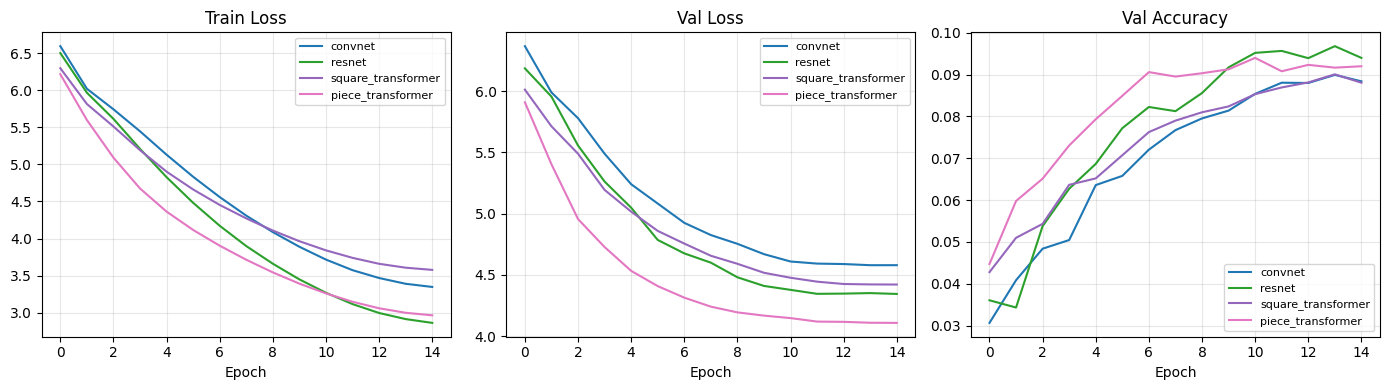

In [16]:
# Plot curves
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

for i, (name, r) in enumerate(results.items()):
    if 'history' not in r:
        continue
    h = r['history']
    axes[0].plot(h['train_loss'], label=name, color=colors[i])
    axes[1].plot(h['val_loss'], label=name, color=colors[i])
    axes[2].plot(h['val_accuracy'], label=name, color=colors[i])

axes[0].set_title('Train Loss')
axes[1].set_title('Val Loss')
axes[2].set_title('Val Accuracy')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.checkpoint_dir, f'curves_chunk{CHUNK_ID}.png'), dpi=150)
plt.show()

## 7. Test Evaluation

In [17]:
def evaluate_test(model_name: str, test_df: pd.DataFrame, config: Config, device: torch.device) -> dict:
    ckpt_path = os.path.join(config.checkpoint_dir, f"{model_name}_best.pt")
    if not os.path.exists(ckpt_path):
        return {'error': 'No checkpoint'}
    
    base_cfg = load_config("config/default.yaml")
    base_cfg.model.backbone = model_name
    base_cfg.model.head = "dual"
    
    model = create_model(base_cfg.model).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device)['model_state_dict'])
    model.eval()
    
    encoder = get_encoder(model_name)
    test_ds = ChessDataset(test_df, encoder)
    test_loader = DataLoader(test_ds, batch_size=config.batch_size, collate_fn=collate_fn)
    
    loss_fn = DualLoss()
    test_loss = correct = total = n = 0
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Test {model_name}"):
            inputs = batch['input']
            if isinstance(inputs, torch.Tensor):
                inputs = inputs.to(device)
            else:
                inputs = {k: v.to(device) if torch.is_tensor(v) else v for k, v in inputs.items()}
            
            out = model(inputs)
            losses = loss_fn(out, batch['policy_target'].to(device), batch['value_target'].to(device))
            test_loss += losses['loss'].item()
            n += 1
            
            pred = out['policy'].argmax(dim=-1)
            target = batch['policy_target'].argmax(dim=-1).to(device)
            correct += (pred == target).sum().item()
            total += pred.size(0)
    
    del model
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    
    return {'test_loss': test_loss / n, 'test_accuracy': correct / total}


print("\nTest Evaluation")
print("="*50)

test_results = {}
for model_name in MODELS_TO_TRAIN:
    if model_name in results and 'error' not in results[model_name]:
        r = evaluate_test(model_name, test_df, config, DEVICE)
        test_results[model_name] = r
        if 'error' not in r:
            print(f"{model_name:<25} Loss: {r['test_loss']:.4f}  Acc: {r['test_accuracy']:.4f}")

with open(os.path.join(config.checkpoint_dir, f"test_chunk{CHUNK_ID}.json"), 'w') as f:
    json.dump(test_results, f, indent=2)


Test Evaluation


Test convnet: 100%|███████████████████████████| 118/118 [00:02<00:00, 43.21it/s]


convnet                   Loss: 4.5114  Acc: 0.0915


Test resnet: 100%|████████████████████████████| 118/118 [00:06<00:00, 17.45it/s]


resnet                    Loss: 4.2966  Acc: 0.0947


Test square_transformer: 100%|████████████████| 118/118 [00:07<00:00, 14.80it/s]


square_transformer        Loss: 4.4025  Acc: 0.0887


Test piece_transformer: 100%|█████████████████| 118/118 [00:05<00:00, 23.28it/s]


piece_transformer         Loss: 4.0533  Acc: 0.0941


In [18]:
# Ranking
print("\n" + "="*50)
print("RANKING (by Test Accuracy)")
print("="*50)

ranked = [(n, r['test_accuracy']) for n, r in test_results.items() if 'test_accuracy' in r]
ranked.sort(key=lambda x: x[1], reverse=True)

for i, (name, acc) in enumerate(ranked):
    medal = ['🥇', '🥈', '🥉'][i] if i < 3 else '  '
    print(f"{medal} {i+1}. {name:<25} {acc*100:.2f}%")


RANKING (by Test Accuracy)
🥇 1. resnet                    9.47%
🥈 2. piece_transformer         9.41%
🥉 3. convnet                   9.15%
   4. square_transformer        8.87%


---
## Continue Training

1. Set `CHUNK_ID = 1` (or next)
2. Set `RESUME_TRAINING = True`
3. Run all cells

**Note**: When resuming, the model uses:
- 10x lower learning rate (`resume_lr_factor = 0.1`)
- Fewer epochs (`resume_epochs = 8`)
- Fresh optimizer (no stale momentum)

This prevents catastrophic forgetting.